<a href="https://colab.research.google.com/github/ariefpurnamamuharram/ariefpurnamamuharram.github.io/blob/master/files/W05_23521013_Arief_Purnama_Muharram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week-5 Assignment: housing.csv
____
Name: Arief Purnama Muharram<br>
Student number: 23521013

In [ ]:
# Install the required packages.
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install tabulate

In [ ]:
# Connect Google Drive

from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import the dataset.
# The dataset used in this case was 'housing.csv'.

import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/housing.csv")

# Shape of the data.
df.shape

(545, 13)

In [ ]:
# Data info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
# Check if any null or missing value.
df.isnull().any().any()

False

In [ ]:
# Check if any duplicated values.
df.duplicated().any()

False

In [ ]:
# Print the top-5 data.
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# Data transformation: the mainroad attribute.
# Change into category codes.

df['mainroad'] = df['mainroad'].astype('category')
df['mainroad'] = df['mainroad'].cat.codes

In [ ]:
# Data transformation: the guestroom attribute.
# Change into category codes.

df['guestroom'] = df['guestroom'].astype('category')
df['guestroom'] = df['guestroom'].cat.codes

In [ ]:
# Data transformation: the basement attribute.
# Change into category codes.

df['basement'] = df['basement'].astype('category')
df['basement'] = df['basement'].cat.codes

In [ ]:
# Data transformation: the hotwaterheating attribute.
# Change into category codes.

df['hotwaterheating'] = df['hotwaterheating'].astype('category')
df['hotwaterheating'] = df['hotwaterheating'].cat.codes

In [ ]:
# Data transformation: the airconditioning attribute.
# Change into category codes.

df['airconditioning'] = df['airconditioning'].astype('category')
df['airconditioning'] = df['airconditioning'].cat.codes

In [ ]:
# Data transformation: the prefarea attribute.
# Change into category codes.

df['prefarea'] = df['prefarea'].astype('category')
df['prefarea'] = df['prefarea'].cat.codes

In [ ]:
# Data transformation: the furnishing attribute.
# Change into category codes as follows,
# - 0   : Not furnished
# - 0.5 : Semi-furnished
# - 1   : Furnished

import numpy as np

df['furnishingstatus'] = np.where(df['furnishingstatus'] == 'furnished', 1, np.where(df['furnishingstatus'] == 'semi-furnished', 0.5, 0))

In [ ]:
# Print the top-5 data.
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0.5
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1.0


In [ ]:
# Statistical description of the data.
df.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.858716,0.177982,0.350459,0.045872,0.315596,0.693578,0.234862,0.465138
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302,0.380686
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000


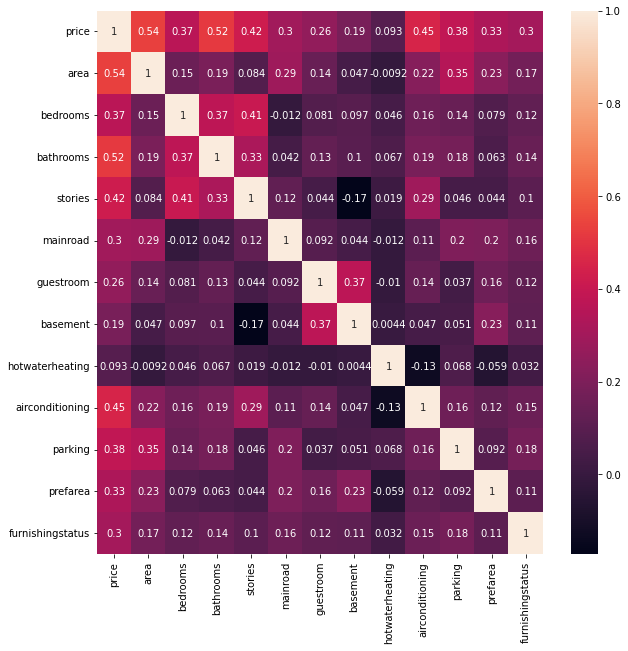

In [ ]:
# Get the data attribute correlation information.

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10,10))  
sns.heatmap(df.corr(), annot=True, ax=ax)

## Multiple Linear Regression
___

In [ ]:
# Split the experiment.

# Experiment 1: Include all data attributes.
X_first_experiment = df.drop(columns=['price'])
y_first_experiment = df['price']

# Experiment 2: Using feature selection approach.
# In this case, I try to choose 3 top correlated attributes.
# The features selected in the experiment 2 include:
# - area
# - bathrooms
# - airconditioning
X_second_experiment = df.drop(columns=['price', 'stories', 'parking', 'prefarea', 'bedrooms', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'furnishingstatus'])
y_second_experiment = df['price']

# Experiment 3: Using feature selection approach.
# In this case, I try to choose 6 top correlated attributes.
# The features selected in the experiment 2 include:
# - area
# - bathrooms
# - airconditioning
# - stories
# - parking
# - prefarea
X_third_experiment = df.drop(columns=['price', 'bedrooms', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'furnishingstatus'])
y_third_experiment = df['price']

In [ ]:
# Create train and test dataset.

from sklearn.model_selection import train_test_split

X_first_train, X_first_test, y_first_train, y_first_test = train_test_split(
    X_first_experiment, y_first_experiment, test_size=0.3
)

X_second_train, X_second_test, y_second_train, y_second_test = train_test_split(
    X_second_experiment, y_second_experiment, test_size=0.3
)

X_third_train, X_third_test, y_third_train, y_third_test = train_test_split(
    X_third_experiment, y_third_experiment, test_size=0.3
)

In [ ]:
# Create the model.

from sklearn import linear_model

regr_first = linear_model.LinearRegression()
regr_second = linear_model.LinearRegression()
regr_third = linear_model.LinearRegression()

regr_first.fit(X_first_train, y_first_train)
regr_second.fit(X_second_train, y_second_train)
regr_third.fit(X_third_train, y_third_train)

print('First Experiment')
print('=====================')
print('coef:', regr_first.coef_, 'intercept:', regr_first.intercept_, '\n\n')

print('Second Experiment')
print('=====================')
print('coef:', regr_second.coef_, 'intercept:', regr_second.intercept_, '\n\n')

print('Third Experiment')
print('=====================')
print('coef:', regr_third.coef_, 'intercept:', regr_third.intercept_)

First Experiment
coef: [2.53281692e+02 8.40129385e+04 9.77591620e+05 4.74669199e+05
 4.20813612e+05 1.57953749e+05 3.03970477e+05 7.07259360e+05
 8.65690906e+05 3.00775084e+05 7.37512383e+05 4.94471426e+05] intercept: -341280.90582978074 


Second Experiment
coef: [3.26441113e+02 1.44144160e+06 1.02056839e+06] intercept: 866808.8285398125 


Third Experiment
coef: [2.86727167e+02 1.17825254e+06 4.25779748e+05 9.21902018e+05
 2.83752020e+05 7.34616901e+05] intercept: 377389.6449234085


In [ ]:
# Create prediction.

pred_first = regr_first.predict(X_first_test)
pred_second = regr_second.predict(X_second_test)
pred_third = regr_third.predict(X_third_test)

In [ ]:
# Make evaluation

from tabulate import tabulate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

table = [
         ['Experiment 1 (all attributes)', mean_absolute_error(y_first_test, pred_first), mean_squared_error(y_first_test, pred_first), r2_score(y_first_test, pred_first)],
         ['Experiment 2 (three attributes)', mean_absolute_error(y_second_test, pred_second), mean_squared_error(y_second_test, pred_second), r2_score(y_second_test, pred_second)],
         ['Experiment 3 (six attributes)', mean_absolute_error(y_third_test, pred_third), mean_squared_error(y_third_test, pred_third), r2_score(y_third_test, pred_third)]
]

print(tabulate(table, headers=['Metrics', 'Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'R-Squared'], floatfmt='.3f'))

Metrics                            Mean Absolute Error (MAE)    Mean Squared Error (MSE)    R-Squared
-------------------------------  ---------------------------  --------------------------  -----------
Experiment 1 (all attributes)                     833925.182           1235374371230.757        0.650
Experiment 2 (three attributes)                  1000927.862           1934226334314.548        0.533
Experiment 3 (six attributes)                     802060.053           1125189000187.357        0.644


### Conclusion and lesson learned
* This experiment is trying to predict the house pricing by its data attributes using the multiple linear regression approach.
* In theory, correlation analysis is needed to decide which features should included. * The stronger the correlation (~1) the most likely the feature is important and should be included.
* However, in this experiment, the results show that the more attributes to be included the more the results better (shown by the reduction of MAE, MSE, and increase of R-squared).
* Multiple linear regression can be used to predict house pricing.

### References
* sklearn.linear_model.LinearRegression, Scikit-learn, available from: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
* Metrics and scoring: quantifying the quality of predictions, Scikit-learn, available from: https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics
* Performance metrics in classification and regression, available from: https://iq.opengenus.org/performance-metrics-in-classification-regression/#:~:text=Performance%20Metrics%20for%20Regression&text=Mean%20Absolute%20Error%20(MAE),R%2DSquared
* Evaluating a linear regression model, Ritchie Ng, Available from: https://www.ritchieng.com/machine-learning-evaluate-linear-regression-model/
* How to easily create tables in python, Matalka L, Medium, available from: https://towardsdatascience.com/how-to-easily-create-tables-in-python-2eaea447d8fd


## Logistic Regression
___

In [ ]:
# I don't have any sufficient information regarding the business case of doing
# logistic regression to this data. So, I try to predict wether a kind of house
# is in prefarea based on several data attributes using the logistic regression
# approach.

In [ ]:
# Create train and test dataset.

from sklearn.model_selection import train_test_split

X = df.drop(columns=['prefarea'])
y = df['prefarea']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3
)

In [ ]:
# Create and train the model.

from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Make prediction

log_pred = logreg.predict(X_test)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.77


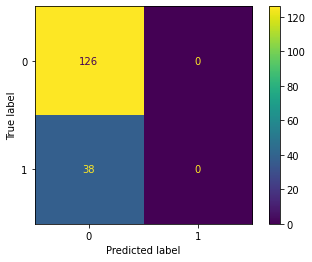

In [ ]:
# Evaluation metrics: confusion matrix.

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

confusion_matrix = confusion_matrix(y_test, log_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix, display_labels=logreg.classes_
)

disp.plot()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.77      1.00      0.87       126
           1       0.00      0.00      0.00        38

    accuracy                           0.77       164
   macro avg       0.38      0.50      0.43       164
weighted avg       0.59      0.77      0.67       164



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Conclusion and lesson learned
* Logistic regression is a process of modeling the probability of a discrete outcome given an input variable (Edgar et al., 2017). 
* Business scenario explanation is important before deciding which attribute should be the class.
* This experiment fails to show the use of logistic regression in predicting 'prefarea' of a house (poor model performance).

### References
* Building a logistic regression in Python step by step, Li S, Medium, available from: https://towardsdatascience.com/building-a-logistic-regression-in-python-step-by-step-becd4d56c9c8
* sklearn.linear_model.LogisticRegression, Scikit-learn, available from: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html